In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import configuration
from Datasets.config.diabetes_config import (
    DATASET_PATH, MODEL_PATH, TARGET_COLUMN, TEST_SIZE, RANDOM_STATE,
    NUMERIC_COLS_MISSING, CATEGORICAL_COLS, MODEL_PARAMS
)

# Import reusable functions
from src.preprocess import load_dataset, explore_data, handle_missing_numeric, handle_missing_categorical, encode_categorical, scale_features, split_data
from src.train import train_model, evaluate_model, save_model, get_feature_importance
from src.utils import print_section, print_subsection, plot_feature_importance, plot_confusion_matrix, print_dataset_summary

In [ ]:
data = pd.read_csv(DATASET_PATH)
data.head()

In [13]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 42 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient_ID                  50000 non-null  int64  
 1   Age                         49503 non-null  float64
 2   Gender                      50000 non-null  str    
 3   Country                     50000 non-null  str    
 4   Height_cm                   47055 non-null  float64
 5   Weight_kg                   47038 non-null  float64
 6   BMI                         50000 non-null  float64
 7   Waist_Circumference_cm      50000 non-null  float64
 8   Blood_Glucose               49041 non-null  float64
 9   HbA1c                       48026 non-null  float64
 10  Fasting_Blood_Sugar         50000 non-null  float64
 11  Insulin_Level               50000 non-null  float64
 12  Blood_Pressure_Systolic     50000 non-null  int64  
 13  Blood_Pressure_Diastolic    50000 non-null

In [6]:
data.shape

(50000, 42)

In [7]:
data.describe()

,Patient_ID,Age,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,Fasting_Blood_Sugar,Insulin_Level,...,Total_Cholesterol,HDL,LDL,Triglycerides,Heart_Rate,Exercise_Hours_Per_Week,Daily_Walking_Minutes,Sleep_Hours,Daily_Water_Intake_L,Diabetes_Risk_Score
count,50000.000000,49503.000000,47055.000000,47038.000000,50000.000000,50000.000000,49041.000000,48026.000000,50000.000000,50000.000000,...,49000.000000,49000.000000,49000.000000,49000.000000,50000.000000,48008.000000,48036.000000,47983.000000,50000.000000,50000.000000
mean,25000.500000,53.871099,170.018814,87.457003,30.924056,99.960790,159.905245,8.488061,142.607294,23.476724,...,220.168635,57.371731,135.014524,229.543259,85.124260,5.017460,89.933442,6.500917,2.998842,74.043920
std,14433.901067,21.130148,14.457787,24.500358,10.290091,23.086579,52.040575,2.313758,44.681799,12.403841,...,57.793626,18.720696,49.135613,98.234911,20.390334,2.875922,52.034642,2.027793,1.152273,15.598327
min,1.000000,18.000000,145.000000,45.000000,11.900000,60.000000,70.000000,4.500000,65.000000,2.000000,...,120.000000,25.000000,50.000000,60.000000,50.000000,0.000000,0.000000,3.000000,1.000000,13.000000
25%,12500.750000,35.000000,157.600000,66.300000,22.700000,80.000000,114.700000,6.500000,103.900000,12.800000,...,169.800000,41.300000,92.500000,144.700000,68.000000,2.500000,44.900000,4.700000,2.000000,64.000000
50%,25000.500000,54.000000,170.000000,87.300000,30.000000,99.800000,159.900000,8.500000,142.600000,23.400000,...,220.400000,57.300000,135.100000,229.500000,85.000000,5.000000,89.800000,6.500000,3.000000,75.000000
75%,37500.250000,72.000000,182.600000,108.600000,37.800000,119.900000,205.100000,10.500000,181.500000,34.300000,...,270.500000,73.600000,177.700000,314.600000,103.000000,7.500000,135.200000,8.300000,4.000000,86.000000
max,50000.000000,90.000000,195.000000,130.000000,61.700000,140.000000,250.000000,12.500000,220.000000,45.000000,...,320.000000,90.000000,220.000000,400.000000,120.000000,10.000000,180.000000,10.000000,5.000000,100.000000


In [17]:
mean = round(data['Age'].mean(),2)
data['Age']=data['Age'].fillna(mean)

In [16]:
data = data.drop(columns=['Height_cm' ,'Weight_kg','Patient_ID'])

In [18]:
data['HbA1c'] = data['HbA1c'].fillna(data['HbA1c'].median())
glucose_level = (28.7*data['HbA1c']) - 46.7
data['Blood_Glucose'] = data['Blood_Glucose'].fillna(glucose_level)

In [85]:
median_glucose_level = glucose_level.median()


In [19]:
data['HDL'] = data['HDL'].fillna(data['HDL'].median())
data['LDL'] = data['LDL'].fillna(data['LDL'].median())
data['Triglycerides'] = data['Triglycerides'].fillna(data['Triglycerides'].median())

In [20]:
Total_Cholesterol_new= data['HDL'] + data['LDL'] + (data['Triglycerides'] / 5)
data['Total_Cholesterol'] = data['Total_Cholesterol'].fillna(Total_Cholesterol_new)

In [21]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         50000 non-null  float64
 1   Gender                      50000 non-null  str    
 2   Country                     50000 non-null  str    
 3   BMI                         50000 non-null  float64
 4   Waist_Circumference_cm      50000 non-null  float64
 5   Blood_Glucose               50000 non-null  float64
 6   HbA1c                       50000 non-null  float64
 7   Fasting_Blood_Sugar         50000 non-null  float64
 8   Insulin_Level               50000 non-null  float64
 9   Blood_Pressure_Systolic     50000 non-null  int64  
 10  Blood_Pressure_Diastolic    50000 non-null  int64  
 11  Total_Cholesterol           50000 non-null  float64
 12  HDL                         50000 non-null  float64
 13  LDL                         50000 non-null

In [22]:
import seaborn as sns 
import matplotlib.pyplot as plt

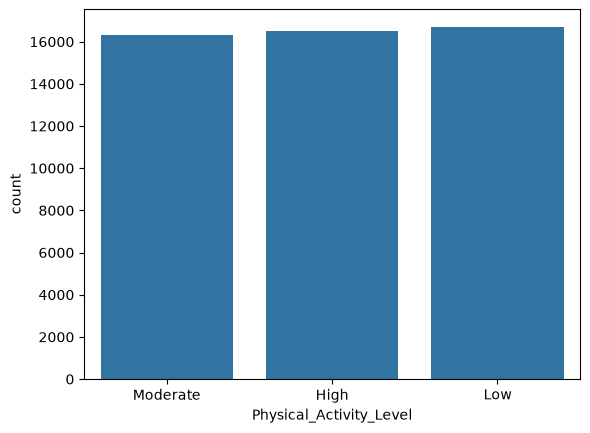

In [23]:
sns.countplot(data=data , x = data['Physical_Activity_Level'])
plt.show()

In [25]:
data['Physical_Activity_Level']=data['Physical_Activity_Level'].fillna(data['Physical_Activity_Level'].mode()[0]) 

In [26]:
num_cols = [ 'Exercise_Hours_Per_Week', 'Daily_Walking_Minutes', 'Sleep_Hours']
data[num_cols] = data[num_cols].fillna(data[num_cols].median())

data['Medication_Adherence'] = data['Medication_Adherence'].fillna(data['Medication_Adherence'].mode()[0])
print("Total missing values remaining:", data.isna().sum().sum())

Total missing values remaining: 0


In [27]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         50000 non-null  float64
 1   Gender                      50000 non-null  str    
 2   Country                     50000 non-null  str    
 3   BMI                         50000 non-null  float64
 4   Waist_Circumference_cm      50000 non-null  float64
 5   Blood_Glucose               50000 non-null  float64
 6   HbA1c                       50000 non-null  float64
 7   Fasting_Blood_Sugar         50000 non-null  float64
 8   Insulin_Level               50000 non-null  float64
 9   Blood_Pressure_Systolic     50000 non-null  int64  
 10  Blood_Pressure_Diastolic    50000 non-null  int64  
 11  Total_Cholesterol           50000 non-null  float64
 12  HDL                         50000 non-null  float64
 13  LDL                         50000 non-null

1️⃣ Data Loading & Exploration

●Load the dataset and perform basic exploration.

●7Tasks to include:

●Load dataset using Pandas

●Show first few rows (head())

●Check dataset shape

●Check for missing values

●Show basic statistics (describe())

●Any other u feel necessary

2️⃣ Data Preprocessing

Prepare the data for training.

Steps:

●Separate features (X) and target (y)

●Perform Train/Test Split

Example:

●80% Training

●20% Testing

3️⃣ Model Training

Train at least 2 different classification models from the list below.

●Choose any two or more:

●Logistic Regression

●Random Forest

●Support Vector Machine (SVM)

●Decision Tree

●K-Nearest Neighbors (KNN)

Model Evaluation
Evaluate each model using the following metrics:

●Accuracy

●Precision

●Recall

●F1 Score

●ROC-AUC Score

Students must also plot the ROC Curve for the models.

Example metrics code concept:

accuracy_score

precision_score

recall_score

f1_score

roc_auc_score

Plot:

●ROC Curve

●Compare models visually

Best Model Selection

●Compare performance of all models

●Choose the best performing model

Save the model using joblib

Example:

import joblib

joblib.dump(model, "diabetes_model.pkl")

📊 Expected Output
●Students should show:

●Dataset exploration

●Data preprocessing

●Training of at least 2 models

●Evaluation metrics

●ROC Curve visualization

●ROC-AUC score comparison

●Saving the best model

🗂 Submission Checklist
Students must submit:

✅ Google Colab Notebook

✅ Dataset loaded and processed

✅ At least 2 models trained

✅ Evaluation metrics printed

✅ ROC Curve plotted

✅ ROC-AUC score calculated

✅ Best model saved using joblib

📤 Submission Instructions
Submit:

●Google Colab Notebook Link

●Access must be set to "Anyone with the link can view"

In [106]:
from sklearn.preprocessing import StandardScaler,LabelEncoder,OrdinalEncoder,OneHotEncoder

In [107]:
data.head()

,Age,Gender,Country,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,Fasting_Blood_Sugar,Insulin_Level,Blood_Pressure_Systolic,...,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Diabetes_Risk,BMI_CATEGORY
0,32.0,Male,Mexico,19.8,71.2,88.4,10.4,149.5,27.4,94,...,No,Good,Retired,Rural,4.4,60,Healthy Diet Plan,Yes,Moderate,Normal
1,42.0,Other,Saudi Arabia,45.9,121.8,247.3,11.3,199.3,18.3,148,...,Yes,Average,Government,Rural,2.1,99,Begin Diabetes Management Plan,Yes,High,Obese
2,89.0,Other,Argentina,37.9,131.8,141.9,6.3,219.6,23.9,101,...,No,Average,Government,Urban,2.8,80,Strict Blood Sugar Monitoring,Yes,High,Obese
3,87.0,Other,United States,26.3,99.1,90.1,7.4,217.7,36.7,120,...,No,Average,Business,Rural,1.5,82,Begin Diabetes Management Plan,Yes,High,Overweight
4,27.0,Other,Australia,41.4,77.1,93.8,12.0,153.5,22.3,190,...,Yes,Poor,Private,Rural,1.6,93,Begin Diabetes Management Plan,Yes,High,Obese


In [31]:
data['Country'].nunique()

25

In [32]:
data['Medication_Adherence'].nunique()

3

In [33]:
data['Work_Type'].nunique()

5

In [ ]:
2  Stress_Level                50000 non-null  str    
 23  Smoking_Status              50000 non-null  str    
 24  Alcohol_Consumption         50000 non-null  str    
 25  Family_History_Diabetes     50000 non-null  str    
 26  Hypertension                50000 non-null  str    
 27  Heart_Disease               50000 non-null  str    
 28  Fatty_Liver                 50000 non-null  str    
 29  PCOS 

In [104]:
data['PCOS'].value_counts()

PCOS
No     25071
Yes    24929
Name: count, dtype: int64

In [40]:
data['AI_Health_Recommendation'].value_counts()

AI_Health_Recommendation
Strict Blood Sugar Monitoring          7481
Immediate Lifestyle Intervention       7419
Consult Endocrinologist Immediately    7271
Medical Evaluation Required            7230
Begin Diabetes Management Plan         7192
Weight Management Program              2616
Reduce Sugar Intake                    2615
Monitor Blood Glucose                  2582
Increase Physical Activity             2564
Healthy Diet Plan                      2560
Exercise Regularly                      113
Balanced Diet                           100
Routine Health Checkup                   91
Annual Diabetes Screening                86
Maintain Healthy Lifestyle               80
Name: count, dtype: int64

In [108]:
from sklearn.model_selection import train_test_split
X = data.drop(columns=['Diabetes_Risk'])
y = data['Diabetes_Risk'].to_numpy()

In [140]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers = [
        ('ordinal_enc' ,OrdinalEncoder(),['Gender','Medication_Adherence','Heart_Disease',
'Hypertension','Alcohol_Consumption','Smoking_Status','PCOS','Work_Type','Fatty_Liver','Stress_Level', 'Residence_Type','BMI_CATEGORY','Family_History_Diabetes']),
        ('onehot_enc' ,OneHotEncoder(drop='first',sparse_output=False),['Country'])],
        remainder='drop'
        )
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state =42)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)
features = preprocessor.get_feature_names_out()
X_train_df = pd.DataFrame(X_train_encoded,columns =features,index=X_train.index )
X_test_df = pd.DataFrame(X_test_encoded,columns =features,index=X_test.index )

In [141]:
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

In [117]:
data['Family_History_Diabetes']

0        Yes
1        Yes
2        Yes
3        Yes
4         No
        ... 
49995    Yes
49996     No
49997    Yes
49998     No
49999     No
Name: Family_History_Diabetes, Length: 50000, dtype: str

In [118]:
data["Diabetes_Risk"].value_counts()

Diabetes_Risk
High        36593
Moderate    12937
Low           470
Name: count, dtype: int64

In [119]:
X_train_df.head()


,ordinal_enc__Gender,ordinal_enc__Medication_Adherence,ordinal_enc__Heart_Disease,ordinal_enc__Hypertension,ordinal_enc__Alcohol_Consumption,ordinal_enc__Smoking_Status,ordinal_enc__PCOS,ordinal_enc__Work_Type,ordinal_enc__Fatty_Liver,ordinal_enc__Stress_Level,...,onehot_enc__AI_Health_Recommendation_Healthy Diet Plan,onehot_enc__AI_Health_Recommendation_Immediate Lifestyle Intervention,onehot_enc__AI_Health_Recommendation_Increase Physical Activity,onehot_enc__AI_Health_Recommendation_Maintain Healthy Lifestyle,onehot_enc__AI_Health_Recommendation_Medical Evaluation Required,onehot_enc__AI_Health_Recommendation_Monitor Blood Glucose,onehot_enc__AI_Health_Recommendation_Reduce Sugar Intake,onehot_enc__AI_Health_Recommendation_Routine Health Checkup,onehot_enc__AI_Health_Recommendation_Strict Blood Sugar Monitoring,onehot_enc__AI_Health_Recommendation_Weight Management Program
39087,0.0,0.0,0.0,0.0,2.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
30893,1.0,1.0,0.0,1.0,1.0,1.0,1.0,3.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
45278,0.0,1.0,0.0,0.0,2.0,0.0,1.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16398,0.0,2.0,1.0,1.0,0.0,1.0,0.0,3.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
13653,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [120]:
y_train_encoded.shape

(40000,)

In [142]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,roc_auc_score ,roc_curve


In [143]:
lr = LogisticRegression(max_iter=1000,random_state=42)
rf = RandomForestClassifier(n_estimators=100,max_features='log2',min_samples_leaf=100,min_samples_split=300,bootstrap=True,max_samples =25000,oob_score=True,random_state=42)


In [144]:
lr.fit(X_train_df,y_train_encoded)
y_pred = lr.predict(X_test_df)
y_pred_proba = lr.predict_proba(X_test_df)[:,1]
print(f" Classification Report is Below :\n{classification_report(y_test_encoded,y_pred)}")

 Classification Report is Below :
              precision    recall  f1-score   support

           0       0.76      0.95      0.84      7304
           1       0.00      0.00      0.00        82
           2       0.55      0.19      0.28      2614

    accuracy                           0.74     10000
   macro avg       0.44      0.38      0.37     10000
weighted avg       0.70      0.74      0.69     10000



D:\Downloads_D\MinicondaFile\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Downloads_D\MinicondaFile\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Downloads_D\MinicondaFile\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [145]:
y_pred_proba


array([0.000414  , 0.02508549, 0.007881  , ..., 0.00649639, 0.00803927,
       0.01664417], shape=(10000,))

In [149]:
rf.fit(X_train_df,y_train_encoded)
y_pred = rf.predict(X_test_df)
print(f" Classification Report is Below :\n{classification_report(y_test_encoded,y_pred)}")

 Classification Report is Below :
              precision    recall  f1-score   support

           0       0.73      1.00      0.85      7304
           1       0.00      0.00      0.00        82
           2       0.68      0.02      0.04      2614

    accuracy                           0.73     10000
   macro avg       0.47      0.34      0.30     10000
weighted avg       0.71      0.73      0.63     10000



D:\Downloads_D\MinicondaFile\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Downloads_D\MinicondaFile\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Downloads_D\MinicondaFile\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


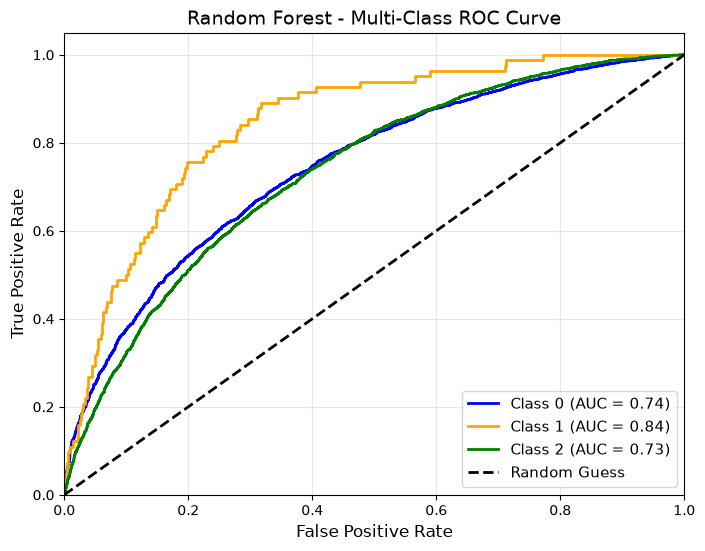

In [150]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# 1. Binarize the test labels for all 3 classes
y_test_binarized = label_binarize(y_test_encoded, classes=[0, 1, 2])
n_classes = y_test_binarized.shape[1]

# 2. Get the prediction probabilities from your Random Forest model
y_pred_proba_rf = rf.predict_proba(X_test_df)

# 3. Plotting the ROC curves
plt.figure(figsize=(8, 6))
colors = ['blue', 'orange', 'green']

for i in range(n_classes):
    fpr, tpr, thresholds = roc_curve(y_test_binarized[:, i], y_pred_proba_rf[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(
        fpr, tpr, 
        color=colors[i], 
        lw=2, 
        label=f'Class {i} (AUC = {roc_auc:.2f})'
    )

# Formatting the plot
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Random Forest - Multi-Class ROC Curve', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.show()

In [97]:
X_train_df.head()

,ordinal_enc__Gender,ordinal_enc__Medication_Adherence,ordinal_enc__Work_Type,ordinal_enc__Residence_Type,ordinal_enc__BMI_CATEGORY,onehot_enc__Country_Australia,onehot_enc__Country_Bangladesh,onehot_enc__Country_Brazil,onehot_enc__Country_Canada,onehot_enc__Country_China,...,remainder__Smoking_Status,remainder__Alcohol_Consumption,remainder__Family_History_Diabetes,remainder__Hypertension,remainder__Heart_Disease,remainder__Fatty_Liver,remainder__PCOS,remainder__Daily_Water_Intake_L,remainder__Diabetes_Risk_Score,remainder__Doctor_Consultation_Needed
39087,0.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,...,Former,Occasionally,Yes,No,No,No,No,4.1,70,Yes
30893,1.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Former,Never,No,Yes,No,Yes,Yes,1.1,54,Yes
45278,0.0,1.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Current,Occasionally,Yes,No,No,No,Yes,3.8,69,Yes
16398,0.0,2.0,3.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,...,Former,Frequently,Yes,Yes,Yes,Yes,No,3.1,67,Yes
13653,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Former,Never,No,No,Yes,No,Yes,2.5,73,Yes


In [147]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


y_test_binarized = label_binarize(y_test_encoded, classes=[0, 1, 2])


y_pred_proba_all = lr.predict_proba(X_test_df)


class_index = 1  
fpr, tpr, thresholds = roc_curve(y_test_binarized[:, class_index], y_pred_proba_all[:, class_index])
roc_auc = auc(fpr, tpr)

print(f"AUC for class {class_index}: {roc_auc:.4f}")

AUC for class 1: 0.8138


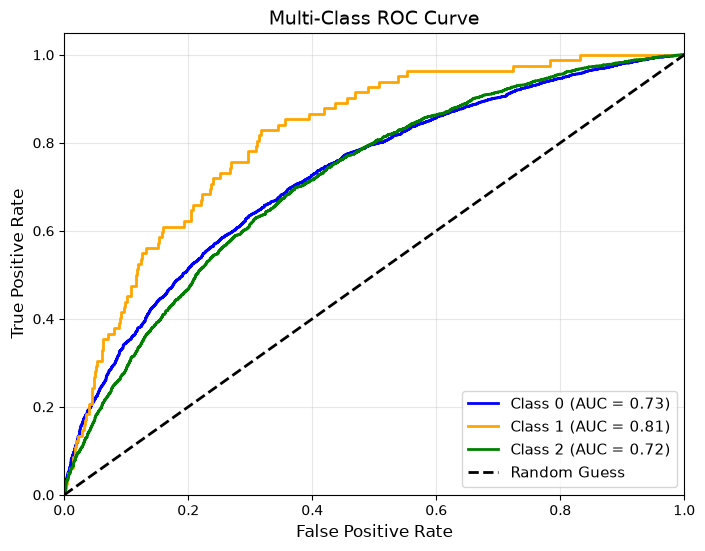

In [148]:
import matplotlib.pyplot as plt

# --- Your existing code ---
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_binarized = label_binarize(y_test_encoded, classes=[0, 1, 2])
y_pred_proba_all = lr.predict_proba(X_test_df)
n_classes = y_test_binarized.shape[1]

# --- What to add: The Plotting Code ---
plt.figure(figsize=(8, 6))
colors = ['blue', 'orange', 'green']

for i in range(n_classes):
    fpr, tpr, thresholds = roc_curve(y_test_binarized[:, i], y_pred_proba_all[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(
        fpr, tpr, 
        color=colors[i], 
        lw=2, 
        label=f'Class {i} (AUC = {roc_auc:.2f})'
    )

# Formatting the plot
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Multi-Class ROC Curve', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.show()

## RANDOM FOREST model worked well then logistic regression